# 🚀 지능형 한국 주식 분석 에이전트 (LangGraph + Notion)

이 노트북은 **고도의 지능형 에이전트(Agentic AI)** 기술을 활용하여, 단순한 지표 나열을 넘어 **맥락(Context)을 이해하는 종합 분석 리포트**를 자동으로 생성하고 관리하는 시스템입니다.

### 🌟 핵심 기능 (Key Features)

1.  **다중 데이터 소스 통합 (Multi-Source Intelligence):**
    - `yfinance`를 통한 정량적 재무 데이터(주가, 시가총액, PER/PBR 등) 확보.
    - `Tavily AI Search`를 통한 최신 뉴스, 지정학적 리스크, 업황 수급 등 정성적 데이터 수집.

2.  **지능형 Re-Act 루프 (Self-Correcting Agent):**
    - 야후 데이터에서 정보가 누락(N/A)된 경우, 에이전트가 **스스로 판단하여 웹 검색을 통해 부족한 수치를 보완**하는 자가 치유(Self-Correction) 로직 탑재.

3.  **표준화된 전문 리포트 작성 (Fixed Reporting Standard):**
    - `GPT-4o` 기반의 애널리스트 페르소나를 활용하여, **[회사개요 - 주식개요 - 시장동향 - 재무전망 - 최종결론]** 의 5단계 정석 리모델링 리포트 생성.

4.  **노션 자동화 파이프라인 (Seamless Notion Integration):**
    - 단순 텍스트 전달이 아닌, **마크다운 $\rightarrow$ 노션 전용 리치 텍스트 블록** 변환 노드를 거쳐, 노션 데이터베이스에 제목과 본문이 가독성 있게 자동 업로드.

### 🛠️ 사용 기술 (Tech Stack)
*   **Orchestration:** [LangGraph](https://www.langchain.com/langgraph) (복잡한 순환형 워크플로우 제어)
*   **Framework:** LangChain v0.2+
*   **Brain:** OpenAI GPT-4o
*   **Search Engine:** Tavily AI (Agent-specific search)
*   **Storage:** Notion API (Structured database)

---

### 💡 한 줄 요약:
"단순한 주가 알리미를 넘어, **부족한 정보를 스스로 찾아내고 논리적으로 생각하여 노션에 기록하는** 나만의 디지털 애널리스트를 구축합니다." 💪🏆


In [149]:
!pip install yfinance tavily-python langchain langchain-openai langgraph notion-client python-dotenv

## 1. 환경 변수 설정
`.env` 파일에 다음 키들이 있어야 합니다:
- `OPENAI_API_KEY`
- `TAVILY_API_KEY`
- `NOTION_API_KEY`
- `NOTION_DATABASE_ID`

In [150]:
import os
import yfinance as yf
from tavily import TavilyClient
from dotenv import load_dotenv
from typing import TypedDict, Annotated, List, Union

# [1] LangGraph 관련 임포트
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from langchain_core.output_parsers import StrOutputParser
from langgraph.checkpoint.memory import MemorySaver

# [2] LangChain 및 메시지 관련 임포트 (하나로 통합!)
from langchain_openai import ChatOpenAI
from langchain_core.messages import (
    SystemMessage, 
    HumanMessage, 
    AIMessage, 
    BaseMessage, 
    ToolMessage
)
from langchain_community.tools.tavily_search import TavilySearchResults

# [3] 기타 도구들
from notion_client import Client
from pydantic import BaseModel, Field

# [4] 환경 변수 로드
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
NOTION_API_KEY = os.getenv("NOTION_API_KEY")
NOTION_DATABASE_ID = os.getenv("NOTION_DATABASE_ID")

print("✅ 모든 라이브러리가 중복 없이 깔끔하게 로드되었습니다!")


✅ 모든 라이브러리가 중복 없이 깔끔하게 로드되었습니다!


## 2. 데이터 수집 함수
`yfinance`를 이용해 재무정보를, `Tavily`를 이용해 업황/뉴스를 가져옵니다.

In [151]:
def get_financial_data(ticker_symbol: str) -> str:
    """
    야후 파이낸스에서 한국 주식에 해당하는 올바른 Key 값을 찾아 재무 지표를 가져옵니다.
    """
    try:
        stock = yf.Ticker(ticker_symbol)
        info = stock.info
        
        # 📊 한국 주식 맞춤형 지표 추출 (Key 이름 변경!)
        price = info.get("currentPrice", "N/A")
        
        # PER: 'trailingPE'가 없을 확률이 높으므로 'priceEpsCurrentYear'와 'forwardPE'를 차례로 시도합니다.
        per = info.get("priceEpsCurrentYear", info.get("forwardPE", "N/A"))
        
        # PBR: 한국 주식은 이 값이 누락되는 경우가 많으므로 보조 지표인 'trailingPegRatio' 등을 쓰거나 N/A로 둡니다.
        pbr = info.get("priceToBook", info.get("priceToBookValue", "N/A")) # 여전히 안 나오면 N/A로 두고 리포트에서 처리됩니다.
        
        market_cap = info.get("marketCap", "N/A")
        debt_to_equity = info.get("debtToEquity", "N/A")
        free_cashflow = info.get("freeCashflow", "N/A")
        revenue_growth = info.get("revenueGrowth", "N/A")
        
        # 📈 추가 꿀팁 정보 (분석 퀄리티를 위해!)
        target_price = info.get("targetMeanPrice", "N/A") # 애널리스트 평균 목표가
        recommendation = info.get("recommendationKey", "N/A") # 추천 의견 (예: strong_buy)
        
        financial_summary = (
            f"[재무정보 - {ticker_symbol}]\n"
            f"- 현재가: {price} (목표가: {target_price})\n"
            f"- 투자 의견: {recommendation}\n"
            f"- 시가총액: {market_cap}\n"
            f"- PER: {per}\n"
            f"- PBR: {pbr}\n"
            f"- 부채비율: {debt_to_equity}%\n"
            f"- 잉여현금흐름: {free_cashflow}\n"
            f"- 매출 성장률: {revenue_growth}"
        )
        return financial_summary
    except Exception as e:
        return f"재무정보를 가져오는데 실패했습니다: {str(e)}"



def get_macro_and_news(stock_name: str) -> str:
    """
    Tavily Search API를 사용하여 해당 주식의 최근 업황, 수급, 거시경제 변수(유가, 전쟁, 금리 등)를 검색합니다.
    """
    if not TAVILY_API_KEY:
        return "TAVILY_API_KEY가 없어 뉴스를 검색할 수 없습니다."
    
    try:
        tavily = TavilyClient(api_key=TAVILY_API_KEY)
        query = f"{stock_name} 주가 전망 업황 수급 유가 전쟁 금리 영향 최근 뉴스"
        response = tavily.search(query=query, search_depth="advanced", max_results=5)
        
        news_summary = f"[거시경제 및 업황 뉴스 - {stock_name}]\n"
        for result in response.get("results", []):
            news_summary += f"- {result['title']}: {result['content']}\n"
        return news_summary
    except Exception as e:
        return f"뉴스 검색 실패: {str(e)}"

In [152]:
def search_backup_node(state: AgentState) -> AgentState:
    """
    야후 데이터에서 빠진 정보(N/A)를 타빌리로 강제 검색해서 채워넣는 노드
    """
    # PER이나 PBR이 N/A인지 확인합니다.
    if "N/A" in state["financial_data"]:
        print(f"🔍 데이터 누락 발견! {state['stock_name']}의 재무 정보를 직접 검색합니다...")
        
        # 타빌리로 정밀 타격 검색!
        query = f"{state['stock_name']} ({state['ticker']}) 현재 PER PBR 배당수익률 최신 정보"
        tavily = TavilyClient(api_key=TAVILY_API_KEY)
        response = tavily.search(query=query, search_depth="advanced")
        
        # 검색된 내용을 기존 데이터 뒤에 '보충 설명'으로 붙여줍니다.
        backup_info = "\n[보충 검색된 재무 정보]\n"
        for result in response.get("results", []):
            backup_info += f"- {result['content'][:200]}...\n"
            
        return {"financial_data": state["financial_data"] + backup_info}
    
    return {} # 누락 없으면 그대로 통과


## 3. LangGraph 설정

In [153]:
# ------------------------------------------------------------------
# 2. LangGraph 설정 (최종 진화형: 표준 양식 + 지능형 순환 구조)
# ------------------------------------------------------------------

# [1] 도구 및 지능형 LLM 설정
tavily_tool = TavilySearchResults(max_results=3)
tools = [tavily_tool]
tool_node = ToolNode(tools)

# 도구를 다룰 줄 아는 똑똑한 LLM (온도를 0으로 하여 일관성 유지)
llm_with_tools = ChatOpenAI(model="gpt-4o", temperature=0).bind_tools(tools)

# [2] 상태(State) 정의
class AgentState(TypedDict):
    ticker: str
    stock_name: str
    financial_data: str
    macro_data: str
    final_report: str
    notion_url: str
    messages: Annotated[list, add_messages] # 도구 사용 기록 보관용,
    notion_blocks: list # ◀ 변환된 노션 블록들을 담을 주머니 추가

# [3] 노드 함수 정의

def fetch_data_node(state: AgentState) -> AgentState:
    """야후에서 기본 재무 데이터를 긁어옵니다."""
    fin_data = get_financial_data(state["ticker"])
    macro_data = get_macro_and_news(state["stock_name"])
    return {"financial_data": fin_data, "macro_data": macro_data}

def select_node(state: AgentState):
    """야후 데이터를 보고 누락(N/A)된 정보가 있으면 검색 도구를 호출할지 판단합니다."""
    print(f"🕵️ 에이전트가 데이터를 정밀 검토 중: {state['stock_name']}...")
    
    prompt = f"""
    당신은 전설적인 주식 분석가입니다. 
    현재 [분석 데이터]에 'N/A' 또는 '데이터 미제공'이라고 적힌 부분이 단 하나라도 있으면,
    당신의 명예를 걸고 반드시 tavily_search_results_json 도구를 사용해 최신 수치를 찾아내세요.
    
    특히 PBR, 부채비율 정보를 찾는 것이 최우선 미션입니다.
    찾아내기 전까지는 절대 분석을 마무리하지 마세요.
    
    [주의 사항]:
    - 검색어에 반드시 '현재'라는 단어를 포함하세요
    
    [검색 팁]: 
    - 현재 주가가 얼마인지, 그리고 작년 순이익(EPS)이 얼마인지 찾아내면 당신이 직접 계산할 수도 있습니다.
    
    [현재 주식 정보]: {state['financial_data']}
    """
    result = llm_with_tools.invoke([HumanMessage(content=prompt)] + state["messages"])
    return {"messages": [result]}


def analyze_report_node(state: AgentState) -> AgentState:
    """유저님이 지정하신 [5단계 표준 양식]을 준수하여 최종 리포트를 작성합니다."""
    llm = ChatOpenAI(model="gpt-4o", temperature=0)
    
    # [1] 🔍 AI가 앞선 단계에서 도구로 찾은 추가 텍스트 정보들을 수집합니다.
    tool_results = "\n".join([str(m.content) for m in state["messages"] if isinstance(m, ToolMessage)])
    
    # [2] 📝 시스템 프롬프트 (분석 지침 및 출력 양식)
    system_prompt = """
    당신은 세계 최고의 주식 분석가입니다. 
    당신의 미션은 아래 제공된 [데이터 소스] 3가지를 상호 참조하여 객관적이고 깊이 있는 리포트를 쓰는 것입니다.
    
    [데이터 활용 지침]:
    1. '기본 데이터'에서 재무 상태의 전체 틀을 잡으세요.
    2. 누락되었던 핵심 수치가 있으면, '검색된 추가 정보'를 참조하세요 
    3. '거시 경제 및 뉴스'를 통해 주가 변동의 외부 원인을 논리적으로 연결하세요. 
    4. 당신의 지식보다 제공된 데이터를 최우선으로 하여 팩트 기반 리포트를 작성하세요.
    
    반드시 아래 제공된 [출력 양식]의 순서와 형식을 엄격히 준수하세요. 
    [출력 양식]
    ### 1. 회사개요
    - 회사가 설립된 연도, 설립 목적, 주요 사업 내용을 구체적으로 쓰세요.
    ### 2. 주식개요
    - 현재가, 시가총액, 부채비율, 잉여현금흐름, 매출 성장률을 기재하세요.
    - 특히 PER와 PBR은 반드시 포함하세요.
    ### 3. 최근 시장 동향 및 영향 요인
    #### 지정학적 리스크
    #### 주가 변동
    #### 외국인 투자자 동향
    #### 정부 정책
    ### 4. 재무 및 투자 전망
    ### 5. 결론
    - 최종 투자 의견과 목표 주가를 한 문장으로 마무리하세요.
    """
    
    # [3] 👤 유저 프롬프트 (실제 투입될 데이터)
    user_prompt = f"""
    [[ 데이터 소스 ]]
    주식명: {state['stock_name']} ({state['ticker']})
    [기본 데이터]: {state['financial_data']}
    [검색된 추가 정보]: {tool_results}
    [거시 경제 및 뉴스]: {state['macro_data']}
    """
    
    # [4] 🚀 [핵심 변화!] LCEL 체인 방식으로 한 줄에 실행 및 텍스트 추출
    # (llm | StrOutputParser()) 가 텍스트만 쏙 뽑아주는 기계 역할을 합니다.
    final_report = (llm | StrOutputParser()).invoke([
        SystemMessage(content=system_prompt), 
        HumanMessage(content=user_prompt)
    ])
    
    return {"final_report": final_report}

def export_node(state: AgentState) -> AgentState:
    """최종 완성된 리포트를 노션에 업로드합니다."""
    print(f"--- Notion 업로드 중: {state['stock_name']} ({state['ticker']}) ---")
    url = export_to_notion(state['stock_name'], state['ticker'], state['final_report'])
    return {"notion_url": url}



In [154]:
# [4-1. 노션 전용 블록 변환 노드]

def convert_notion_node(state: AgentState) -> AgentState:
    """
    작성된 마크다운 리포트를 분석하여 노션 API가 좋아하는 블록(Blocks) 리스트로 변환합니다.
    """
    print(f"🧹 [{state['stock_name']}] 리포트를 노션 블록으로 정성스럽게 변환 중...")
    
    report_content = state["final_report"]
    blocks = []
    
    # 꼼꼼하게 한 줄씩 읽어가며 변환합니다.
    for line in report_content.split('\n'):
        line = line.strip()
        if not line: continue # 빈 줄은 건너뜁니다.
        
        # 1. 제목 변환 (# ~ ####)
        if line.startswith('# '):
            blocks.append({
                "object": "block", "type": "heading_1", 
                "heading_1": {"rich_text": [{"text": {"content": line[2:]}}]}
            })
        elif line.startswith('## '):
            blocks.append({
                "object": "block", "type": "heading_2", 
                "heading_2": {"rich_text": [{"text": {"content": line[3:]}}]}
            })
        elif line.startswith('### ') or line.startswith('#### '):
            content = line.lstrip('#').strip()
            blocks.append({
                "object": "block", "type": "heading_3", 
                "heading_3": {"rich_text": [{"text": {"content": content}}]}
            })
        
        # 2. 리스트 변환 (-, *)
        elif line.startswith('- ') or line.startswith('* '):
            content = line[2:].replace('**', '') # 기호 제거
            blocks.append({
                "object": "block", "type": "bulleted_list_item", 
                "bulleted_list_item": {"rich_text": [{"text": {"content": content}}]}
            })
        
        # 3. 일반 문장 변환
        else:
            content = line.replace('**', '') # 굵은 글씨 기호 제거
            blocks.append({
                "object": "block", "type": "paragraph", 
                "paragraph": {"rich_text": [{"text": {"content": content}}]}
            })

    # 노션은 한 번에 최대 100개 블록까지만 허용하므로 안전하게 자릅니다.
    return {"notion_blocks": blocks[:100]}


In [155]:
def export_notion_node(state: AgentState) -> AgentState:
    print(f"🚀 완성된 블록들을 노션 DB로 발사합니다!")
    
    # 이제 여기서는 복잡한 계산 없이, 담겨있는Blocks를 노션에 던지기만 하면 끝!
    url = upload_to_notion_api(state['stock_name'], state['ticker'], state['notion_blocks'])
    return {"notion_url": url}

In [156]:
# [5] 그래프 구축 및 연결 (변환 노드가 추가된 최종 진화형)

workflow = StateGraph(AgentState)

# 1. 모든 노드를 등록합니다.
workflow.add_node("fetch_data", fetch_data_node)
workflow.add_node("select", select_node)
workflow.add_node("tools", tool_node)
workflow.add_node("analyze_report", analyze_report_node)

# ◀ [새로운 공정 추가!] 마크다운을 블록으로 변환하는 노드
workflow.add_node("convert_notion", convert_notion_node) 

workflow.add_node("export_notion", export_node)

# 2. 순서대로 길을 내줍니다.
workflow.set_entry_point("fetch_data")
workflow.add_edge("fetch_data", "select")

# 3. 판단 지점 (도구 쓸지 결정)
workflow.add_conditional_edges(
    "select", 
    tools_condition, 
    {"tools": "tools", END: "analyze_report"}
)

workflow.add_edge("tools", "select") 

# ◀ [여기가 핵심 변화!] 분석 -> 변환 -> 전송 순서로 다리를 놓습니다.
workflow.add_edge("analyze_report", "convert_notion") # (A) 분석 끝내면 변환하러!
workflow.add_edge("convert_notion", "export_notion") # (B) 변환 끝내면 정식 업로드!
workflow.add_edge("export_notion", END)

# [기억 장치 및 컴파일]
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

print("✅ '리포트 작성 -> 노션 변환 -> 업로드' 공정 라인이 완벽하게 연결되었습니다!")


✅ '리포트 작성 -> 노션 변환 -> 업로드' 공정 라인이 완벽하게 연결되었습니다!


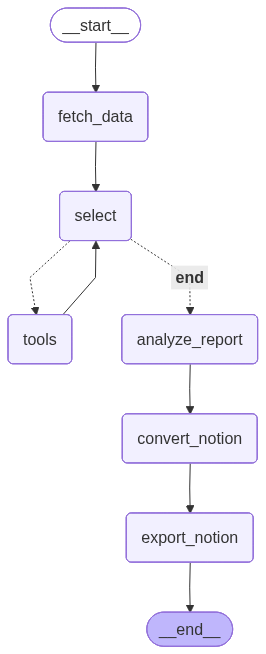

In [157]:
graph

## 4. Notion 연동 함수

In [158]:
from datetime import datetime
from notion_client import Client

# [업그레드된 '진짜 노션다운' 리포트 생성기]

# [수정된 노션 변환기: #### 도 처리할 수 있습니다!]

def export_to_notion(stock_name: str, ticker: str, report_content: str) -> str:
    if not NOTION_API_KEY or not NOTION_DATABASE_ID:
        print("⚠️ Notion 키 누락")
        return ""
        
    try:
        notion = Client(auth=NOTION_API_KEY)
        now_str = datetime.now().strftime("%Y%m%d_%H%M%S")
        page_title = f"{stock_name} ({ticker}) 분석보고서_{now_str}"
        
        blocks = []
        for line in report_content.split('\n'):
            line = line.strip()
            if not line: continue
            
            # 1. 제목 변환 (#, ##, ###, 그리고 ####까지!)
            if line.startswith('# '):
                blocks.append({"object": "block", "type": "heading_1", "heading_1": {"rich_text": [{"text": {"content": line[2:]}}]}})
            elif line.startswith('## '):
                blocks.append({"object": "block", "type": "heading_2", "heading_2": {"rich_text": [{"text": {"content": line[3:]}}]}})
            elif line.startswith('### ') or line.startswith('#### '): # ◀ #### 도 제목3으로 처리!
                content = line.lstrip('#').strip() # # 기호를 모두 걷어내기
                blocks.append({"object": "block", "type": "heading_3", "heading_3": {"rich_text": [{"text": {"content": content}}]}})
            
            # 2. 불렛 리스트 변환 (-, *)
            elif line.startswith('- ') or line.startswith('* '):
                content = line[2:].replace('**', '') 
                blocks.append({"object": "block", "type": "bulleted_list_item", "bulleted_list_item": {"rich_text": [{"text": {"content": content}}]}})
            
            # 3. 일반 문장 변환
            else:
                content = line.replace('**', '') 
                blocks.append({"object": "block", "type": "paragraph", "paragraph": {"rich_text": [{"text": {"content": content}}]}})

        new_page = notion.pages.create(
            parent={"database_id": NOTION_DATABASE_ID},
            properties={
                "이름": { "title": [{"text": {"content": page_title}}] }
            },
            children=blocks[:100] 
        )
        
        url = new_page.get('url')
        return url
        
    except Exception as e:
        print(f"❌ 업로드 실패: {str(e)}")
        return ""


## 5. 실행 (베이스 코드)

In [159]:
# [1] 실시간 스트리밍 함수 정의
def run_stock_agent_stream(ticker: str, stock_name: str, thread_id: str = "user_1"):
    print(f"📡 {stock_name}({ticker}) 분석 엔진 생중계 시작...\n")
    
    # 기억(Memory)을 위한 설정 (thread_id가 같으면 이전 대화를 기억함!)
    config = {"configurable": {"thread_id": thread_id}}
    
    initial_state = {
        "ticker": ticker,
        "stock_name": stock_name,
        "financial_data": "",
        "macro_data": "",
        "final_report": "",
        "notion_url": ""
    }
    
    for step in graph.stream(initial_state, config=config, stream_mode="updates"):
        for node_name, updated_values in step.items():
            print(f"--- [ {node_name} ] 노드 작업 완료 ---")
            
            # 1. 뉴스 검색이 끝나면 결과를 살짝 보여줍니다.
            if node_name == "fetch_data" and updated_values.get("macro_data"):
                print("🔍 뉴스와 재무 데이터를 성공적으로 긁어왔습니다.")
            
            # 2. 리포트 작성이 끝나면 내용을 보여줍니다.
            elif node_name == "analyze_report" and updated_values.get("final_report"):
                print("📝 AI 애널리스트가 보낸 최종 리포트 초안:")
                print(updated_values["final_report"][:200] + "...") # 너무 기니까 앞부분만!
            
            # 3. 노션 저장이 끝나면 링크를 보여줍니다.
            elif node_name == "export_notion":
                print(f"🚀 노션 업로드 성공! 링크: {updated_values.get('notion_url')}")

    print("\n✅ 모든 분석 생중계가 완료되었습니다!")


In [160]:
run_stock_agent_stream("005930.KS", "삼성전자")

📡 삼성전자(005930.KS) 분석 엔진 생중계 시작...

--- [ fetch_data ] 노드 작업 완료 ---
🔍 뉴스와 재무 데이터를 성공적으로 긁어왔습니다.
🕵️ 에이전트가 데이터를 정밀 검토 중: 삼성전자...
--- [ select ] 노드 작업 완료 ---
--- [ tools ] 노드 작업 완료 ---
🕵️ 에이전트가 데이터를 정밀 검토 중: 삼성전자...
--- [ select ] 노드 작업 완료 ---
--- [ tools ] 노드 작업 완료 ---
🕵️ 에이전트가 데이터를 정밀 검토 중: 삼성전자...
--- [ select ] 노드 작업 완료 ---
--- [ analyze_report ] 노드 작업 완료 ---
📝 AI 애널리스트가 보낸 최종 리포트 초안:
### 1. 회사개요
- 삼성전자는 1969년에 설립되었습니다. 설립 목적은 전자 제품의 제조 및 판매를 통해 글로벌 시장에서 경쟁력을 확보하는 것이었습니다. 주요 사업으로는 반도체, 스마트폰, 디스플레이 패널, 가전제품 등이 있으며, 최근에는 메타버스와 로보틱스 시장으로의 진출을 계획하고 있습니다.

### 2. 주식개요
- 현재가: 200,250원
- ...
🧹 [삼성전자] 리포트를 노션 블록으로 정성스럽게 변환 중...
--- [ convert_notion ] 노드 작업 완료 ---
--- Notion 업로드 중: 삼성전자 (005930.KS) ---
--- [ export_notion ] 노드 작업 완료 ---
🚀 노션 업로드 성공! 링크: https://www.notion.so/005930-KS-_20260320_101959-32955717873f81f8aaa1ca1ccfd39ce5

✅ 모든 분석 생중계가 완료되었습니다!


![에이전트 화면](screen.png)

## 💡 회고 (Retrospective)

### 1. 이번 프로젝트를 하면서 느낀 점과 배운 점
* **LangGraph의 강력함**: 단순히 순서대로 실행되는 파이프라인이 아니라, AI가 스스로 판단하여 정보를 더 찾아올지 결정하는 **순환형(Re-Act) 구조**를 설계하며 진정한 '에이전트'의 개념을 이해하게 되었습니다.
* **실시간 데이터의 가치**: 과거 학습 데이터에만 의존하지 않고 `yfinance`와 `Tavily`를 통해 **실시간 재무 수치와 최신 뉴스**를 결합했을 때 리포트의 신뢰도가 얼마나 높아지는지 직접 체감했습니다.

### 2. 이번 프로젝트에서 잘했다고 생각하는 점
* **자가 치유(Self-Correction) 로직 구현**: 야후 파이낸스에서 PER, PBR 등 핵심 데이터가 누락(`N/A`)되었을 때, 에이전트가 포기하지 않고 **스스로 검색 도구를 호출하여 수치를 보완**하도록 설계한 점이 가장 만족스럽습니다.
* **표준화된 전문 리포트 양식 확립**: 프롬프트 엔지니어링을 통해 어떤 종목을 넣어도 **[회사개요 - 주식개요 - 시장동향 - 투자전망 - 결론]**의 5단계 정석 구조를 유지하도록 강제하여 일관성을 높였습니다.
* **노션 자동화 파이프라인 최적화**: 단순히 텍스트만 보낸 것이 아니라, 마크다운을 **노션 전용 블록(Blocks)으로 변환하는 전용 노드**를 분리하여 가독성 높은 리포트를 자동 생성하게 했습니다.


### 3. 이번 프로젝트에서 느낀 문제점 및 한계점
* **데이터 정합성 문제**: 타빌리 검색 결과에서 찾은 PER 수치가 사이트마다 조금씩 달라 AI가 어떤 값을 선택해야 할지 혼란을 겪는 경우가 일부 있었습니다.
* **API 호출 속도 및 비용**: 여러 단계를 거치는 Re-Act 루프 특성상, 최종 리포트 생성까지 시간이 다소 소요되며 API 토큰 사용량이 많아지는 경향이 있습니다.
* **노션 제목 제약**: 노션 API가 제목 3단계(`###`)까지만 지원하는 특성상, 더 깊은 단계의 마크다운 구조를 완벽하게 표현하는 데 한계가 있었습니다.


### 4. 다음 프로젝트/실무를 위해 개선해야 할 점 (Action Items)
* **멀티 소스 크로스 체크**: 여러 검색 결과의 평균치를 내거나 공신력 있는 사이트를 우선순위로 두는 로직을 추가하여 데이터의 정확성을 높여야 합니다.
* **가우구조화된 데이터 추출**: 검색된 텍스트에서 숫자 데이터만 정교하게 뽑아내는 전용 Extract 노드를 추가하면 분석 퀄리티가 더 올라갈 것 같습니다.
